# Instructor Effectiveness Modeling — Assignment Submission

**Name:** Vidhi Pandey  
**Date:** 15 March 2026

## Instructor Effectiveness Modeling (EdTech Case Study)

This notebook analyzes instructor performance using learner outcomes, engagement metrics, and feedback data.

Goal:  
To design a data-driven approach for estimating **Instructor Effectiveness** and build a **machine learning model to classify instructors into effectiveness tiers**.

Dataset: Instructor batch-level performance metrics from an EdTech platform.

## Problem Understanding

The EdTech platform runs the same courses across multiple batches taught by different instructors. Each instructor may teach multiple batches over time.

The platform wants to identify **how effective each instructor is** using available data related to:

• Learner outcomes  
• Student engagement  
• Student feedback  

Since each row in the dataset represents a **course batch**, we must analyze batch-level metrics and later aggregate them to evaluate instructors.

Instructor effectiveness is not explicitly defined in the dataset, so we must create a **reasonable definition using the available metrics**.

## Approach

The analysis will follow the steps below:

1. **Exploratory Data Analysis (EDA)**  
   - Understand distributions of variables  
   - Identify correlations and patterns  
   - Check for missing values or anomalies

2. **Define Instructor Effectiveness Score**  
   - Combine outcome, engagement, and feedback metrics into a composite score.

3. **Aggregate Batch-Level Data to Instructor-Level**  
   - Since instructors teach multiple batches, batch metrics will be aggregated to obtain instructor-level features.

4. **Create Instructor Effectiveness Tiers**  
   - Convert the effectiveness score into categories such as Low, Medium, and High.

5. **Train a Machine Learning Model**  
   - Build a classification model to predict instructor effectiveness tiers.

6. **Evaluate and Interpret the Model**  
   - Analyze important features influencing effectiveness and discuss implications for an EdTech platform.

## Import Required Libraries

The following Python libraries are used for data manipulation, visualization, and machine learning.

In [47]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")

## Load the Dataset

The dataset contains batch-level metrics for courses taught by different instructors.  
Each row represents a **single course batch**.

In [48]:
df = pd.read_csv("instructor_effectiveness_dataset_2000_rows.csv")

df.head()

,batch_id,instructor_id,course_id,completion_rate,avg_score_improvement,avg_quiz_score,dropout_rate,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate
0,B_1861,I_044,C_01,0.300000,14.225955,73.546528,0.647423,0.774572,0.790918,0.108414,3.766211,0.533193
1,B_0354,I_119,C_06,0.657220,22.871110,77.312331,0.425098,0.494936,0.998566,0.280550,5.000000,0.734087
2,B_1334,I_050,C_03,0.300000,16.087517,79.563687,0.700000,0.977901,0.807298,0.207013,3.517386,0.681433
3,B_0906,I_024,C_21,0.639507,24.260687,99.295316,0.334657,0.846515,0.544555,0.306395,4.207578,1.000000
4,B_1290,I_001,C_08,0.527302,31.081556,99.393425,0.521099,0.917450,0.865885,0.252289,4.426230,0.696710


## Dataset Overview

Before performing deeper analysis, we first examine:

• Dataset shape  
• Column names  
• Data types  
• Basic summary statistics

In [49]:
df.shape

(2000, 12)

In [50]:
df.columns

Index(['batch_id', 'instructor_id', 'course_id', 'completion_rate',
       'avg_score_improvement', 'avg_quiz_score', 'dropout_rate',
       'avg_watch_time', 'assignment_submission_rate', 'forum_activity_rate',
       'avg_feedback_score', 'feedback_response_rate'],
      dtype='object')

In [51]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   batch_id                    2000 non-null   object 
 1   instructor_id               2000 non-null   object 
 2   course_id                   2000 non-null   object 
 3   completion_rate             2000 non-null   float64
 4   avg_score_improvement       2000 non-null   float64
 5   avg_quiz_score              2000 non-null   float64
 6   dropout_rate                2000 non-null   float64
 7   avg_watch_time              2000 non-null   float64
 8   assignment_submission_rate  2000 non-null   float64
 9   forum_activity_rate         2000 non-null   float64
 10  avg_feedback_score          2000 non-null   float64
 11  feedback_response_rate      2000 non-null   float64
dtypes: float64(9), object(3)
memory usage: 187.6+ KB


In [52]:
df.describe()

,completion_rate,avg_score_improvement,avg_quiz_score,dropout_rate,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,0.602808,27.035844,77.956126,0.394883,0.776515,0.753188,0.250300,4.207134,0.736519
std,0.159667,5.716641,10.695618,0.162747,0.145231,0.148058,0.100640,0.419209,0.149412
min,0.300000,6.159240,40.386725,0.020000,0.287440,0.251111,0.000000,2.639915,0.259935
25%,0.489260,23.124673,70.897590,0.280035,0.675076,0.652110,0.179845,3.918986,0.633293
50%,0.603091,26.938629,78.020567,0.394820,0.780330,0.756380,0.249771,4.205989,0.737213
75%,0.712797,30.885600,85.444286,0.511432,0.894242,0.856458,0.319204,4.503437,0.845876
max,0.980000,40.000000,100.000000,0.700000,1.000000,1.000000,0.641111,5.000000,1.000000


## Checking for Missing Values

Missing values can affect analysis and model performance.  
We check if any columns contain null values.

In [53]:
df.isnull().sum()

batch_id                      0
instructor_id                 0
course_id                     0
completion_rate               0
avg_score_improvement         0
avg_quiz_score                0
dropout_rate                  0
avg_watch_time                0
assignment_submission_rate    0
forum_activity_rate           0
avg_feedback_score            0
feedback_response_rate        0
dtype: int64

## Feature Distributions

We examine the distributions of important metrics such as:

• Completion rate  
• Dropout rate  
• Quiz scores  
• Engagement metrics  
• Feedback scores  

This helps understand the spread of values and identify potential anomalies.

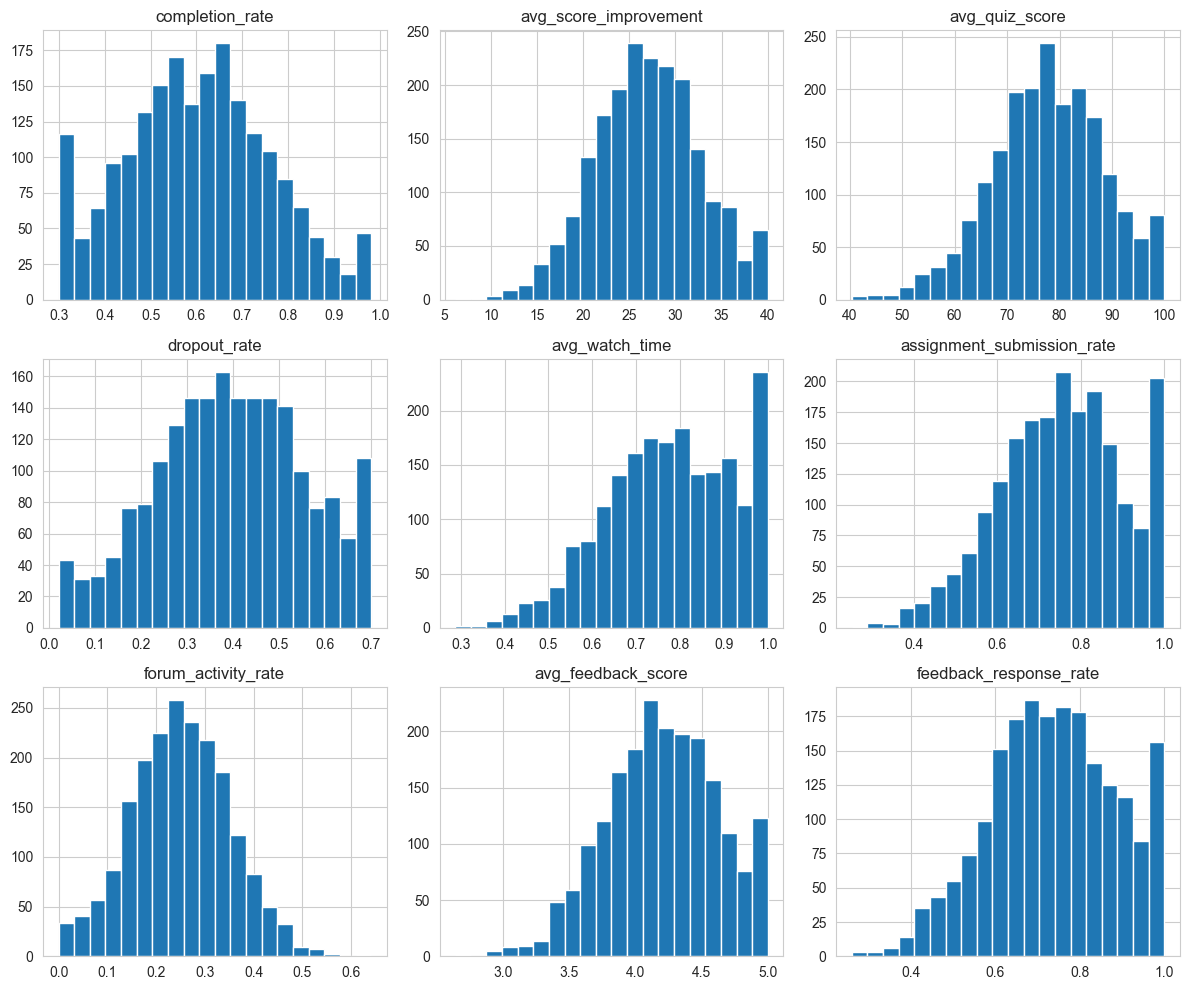

In [54]:
df.hist(figsize=(12,10), bins=20)
plt.tight_layout()
plt.show()

## Correlation Analysis

Correlation analysis helps identify relationships between variables.

For example:

• Completion rate vs dropout rate  
• Engagement metrics vs quiz scores  
• Feedback score vs learner outcomes

A heatmap provides a visual overview of these relationships.

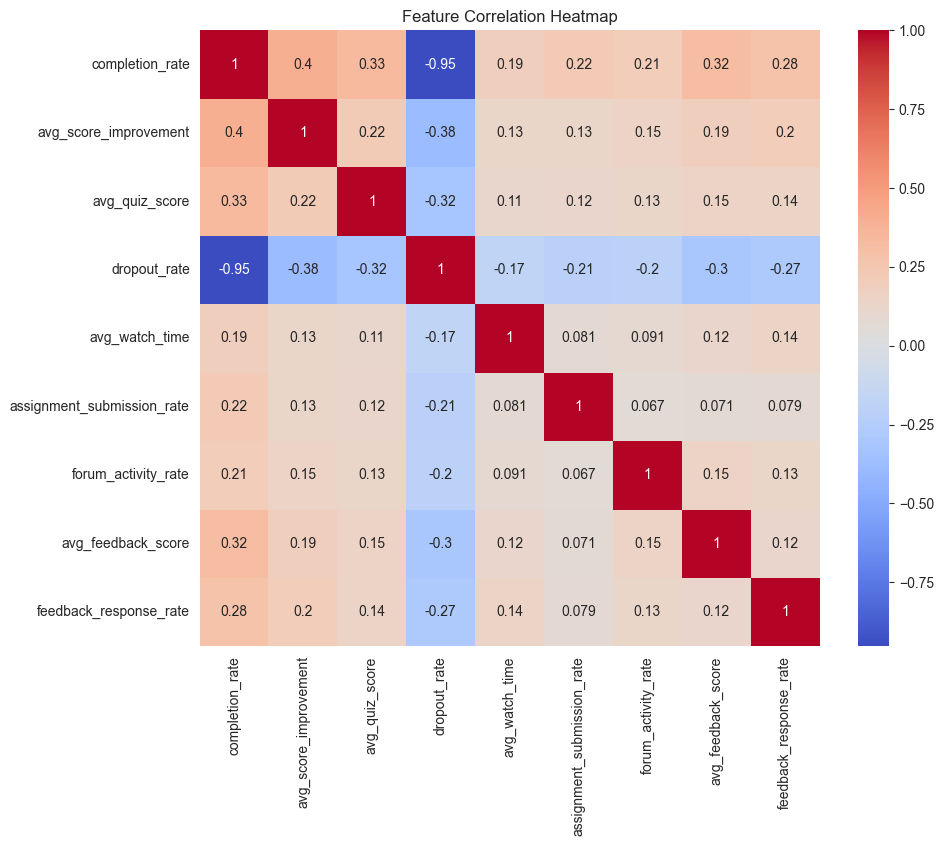

In [55]:
plt.figure(figsize=(10,8))
corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

In [56]:
# number of unique instructors
df['instructor_id'].nunique()
# batches taught per instructor
batches_per_instructor = df.groupby('instructor_id').size()
batches_per_instructor.describe()

count    120.000000
mean      16.666667
std        4.582270
min        7.000000
25%       13.750000
50%       17.000000
75%       19.000000
max       31.000000
dtype: float64

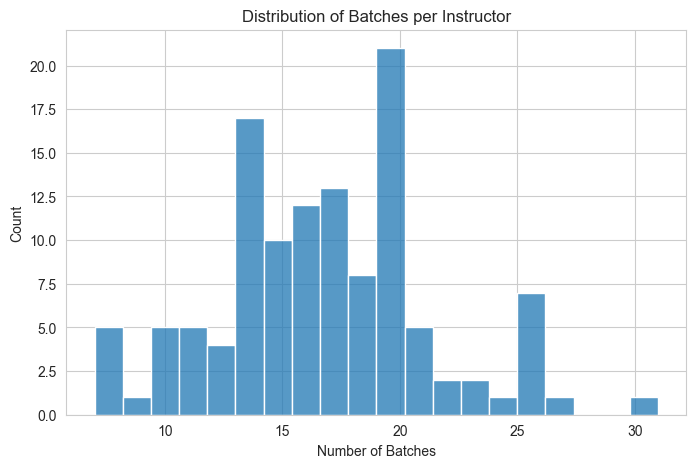

In [57]:
#Distribution of batches per instructor
plt.figure(figsize=(8,5))
sns.histplot(batches_per_instructor, bins=20)
plt.title("Distribution of Batches per Instructor")
plt.xlabel("Number of Batches")
plt.ylabel("Count")
plt.show()

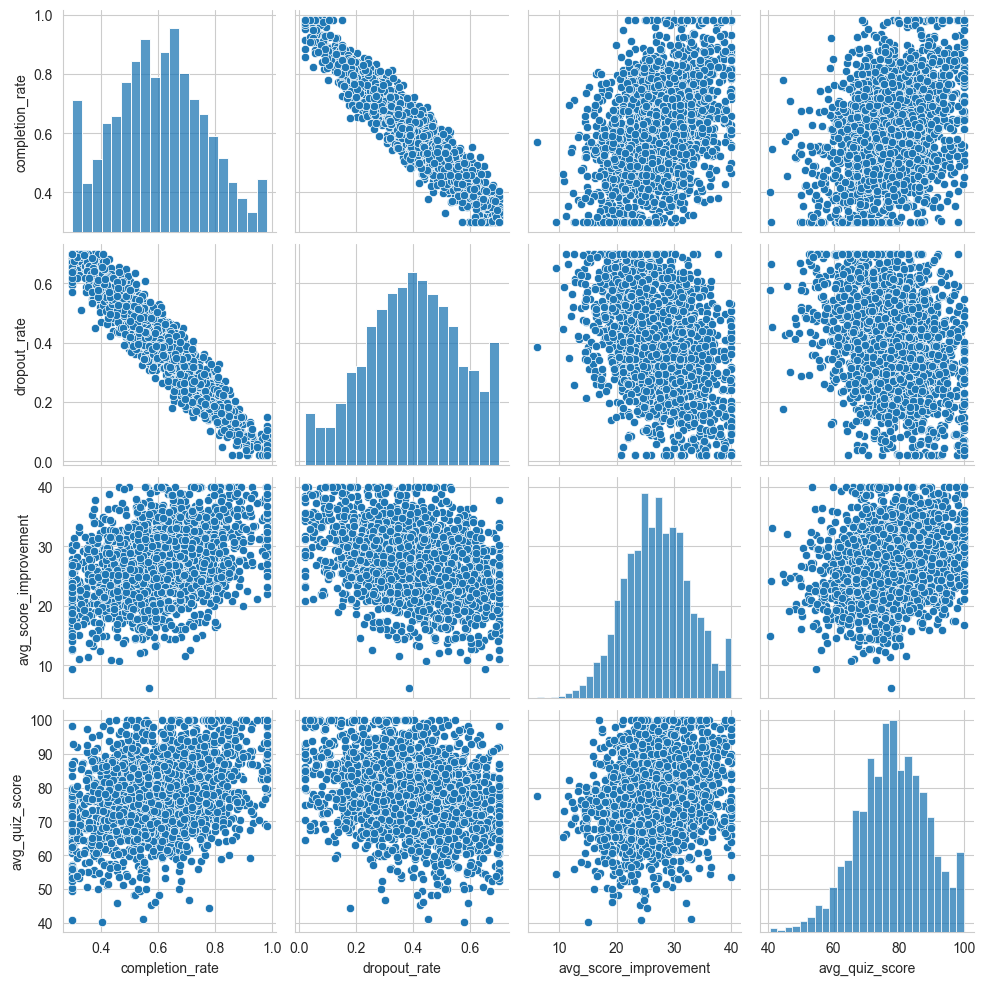

In [58]:
#Pairplot for important outcome variables
selected_cols = [
    'completion_rate',
    'dropout_rate',
    'avg_score_improvement',
    'avg_quiz_score'
]

sns.pairplot(df[selected_cols])
plt.show()

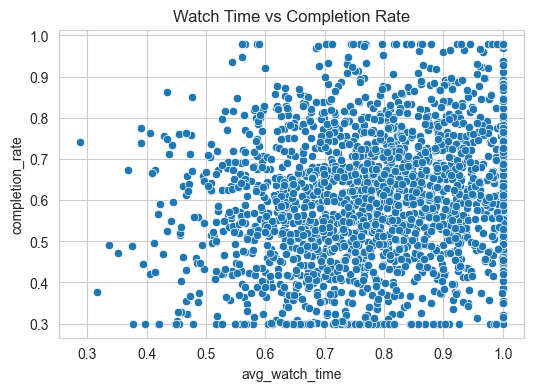

In [59]:
# Engagement vs Completion
plt.figure(figsize=(6,4))
sns.scatterplot(x='avg_watch_time', y='completion_rate', data=df)
plt.title("Watch Time vs Completion Rate")
plt.show()

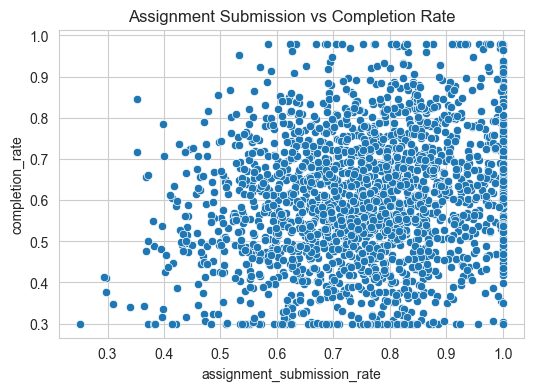

In [60]:
plt.figure(figsize=(6,4))
sns.scatterplot(x='assignment_submission_rate', y='completion_rate', data=df)
plt.title("Assignment Submission vs Completion Rate")
plt.show()

In [61]:
# Engagement Summary
engagement_cols = [
    'avg_watch_time',
    'assignment_submission_rate',
    'forum_activity_rate'
]

df[engagement_cols].describe()

,avg_watch_time,assignment_submission_rate,forum_activity_rate
count,2000.000000,2000.000000,2000.000000
mean,0.776515,0.753188,0.250300
std,0.145231,0.148058,0.100640
min,0.287440,0.251111,0.000000
25%,0.675076,0.652110,0.179845
50%,0.780330,0.756380,0.249771
75%,0.894242,0.856458,0.319204
max,1.000000,1.000000,0.641111


## Initial Observations

From the feature distributions and correlation heatmap, several patterns can be observed:

1. **Completion Rate vs Dropout Rate**
   - Completion rate and dropout rate show a very strong negative correlation (~ -0.95).
   - This is expected because when more students complete the course, fewer drop out.
   - These variables capture opposite aspects of learner retention.

2. **Learning Outcomes**
   - `avg_score_improvement` and `avg_quiz_score` appear moderately correlated with completion rate.
   - This suggests that instructors whose students finish the course are also likely to show stronger learning outcomes.

3. **Engagement Metrics**
   - Metrics such as `avg_watch_time`, `assignment_submission_rate`, and `forum_activity_rate` show mild positive relationships with completion and quiz performance.
   - This indicates that higher engagement may contribute to better learner outcomes.

4. **Feedback Metrics**
   - `avg_feedback_score` and `feedback_response_rate` show small but positive correlations with completion rate.
   - This may indicate that students tend to give better feedback when they are more engaged or satisfied with the instructor.

5. **Distribution Patterns**
   - Most variables appear approximately normally distributed with slight skew.
   - Engagement metrics such as watch time and assignment submission tend to cluster toward higher values, indicating generally active learners.

6. **Low Multicollinearity**
   - Apart from completion rate and dropout rate, most variables have moderate or weak correlations with each other.
   - This suggests the features may provide complementary information when modeling instructor effectiveness.

## Defining Instructor Effectiveness

Instructor effectiveness is not directly provided in the dataset, so we must construct a reasonable proxy using the available metrics.

An effective instructor should demonstrate strong performance across three major dimensions:

### 1. Learner Outcomes
These metrics reflect whether students are successfully learning from the course.

Relevant variables:
- Completion rate
- Average score improvement
- Average quiz score
- Dropout rate

Higher completion and score improvement indicate stronger learning outcomes, while higher dropout rates suggest potential instructional challenges.

### 2. Student Engagement
Engagement measures how actively learners participate in course activities.

Relevant variables:
- Average watch time
- Assignment submission rate
- Forum activity rate

Higher engagement typically indicates that learners find the course content engaging and accessible.

### 3. Learner Satisfaction
Feedback metrics capture student perception of the instructor and course quality.

Relevant variables:
- Average feedback score
- Feedback response rate

Higher feedback scores suggest positive student experiences with the instructor.

### Constructing the Effectiveness Score

To combine these dimensions, a weighted effectiveness score is created.  
The weights reflect the assumption that **learning outcomes are the most important**, followed by engagement and student feedback.

The effectiveness score is computed as:

Effectiveness Score =
0.25 × completion_rate  
+ 0.20 × avg_score_improvement  
+ 0.15 × avg_quiz_score  
+ 0.10 × avg_watch_time  
+ 0.10 × assignment_submission_rate  
+ 0.05 × forum_activity_rate  
+ 0.10 × avg_feedback_score  
+ 0.05 × feedback_response_rate  
− 0.20 × dropout_rate

This score combines multiple aspects of course performance into a single quantitative measure of instructor effectiveness.

### Converting Score into Tiers

To simplify interpretation and enable classification modeling, the effectiveness score will later be converted into categorical tiers:

- **Low Effectiveness**
- **Medium Effectiveness**
- **High Effectiveness**

These tiers will form the target variable for the machine learning model.

In [62]:
df['effectiveness_score'] = (
    0.25 * df['completion_rate']
    + 0.20 * df['avg_score_improvement']
    + 0.15 * df['avg_quiz_score']
    + 0.10 * df['avg_watch_time']
    + 0.10 * df['assignment_submission_rate']
    + 0.05 * df['forum_activity_rate']
    + 0.10 * df['avg_feedback_score']
    + 0.05 * df['feedback_response_rate']
    - 0.20 * df['dropout_rate']
)

In [63]:
df[['effectiveness_score']].describe()

,effectiveness_score
count,2000.000000
mean,17.795338
std,2.214507
min,9.615772
25%,16.301907
50%,17.860333
75%,19.310689
max,23.808687


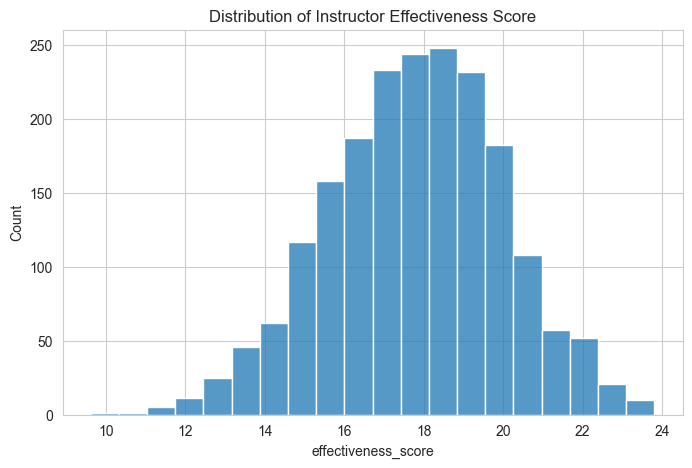

In [64]:
# Distribution of effectiveness score
plt.figure(figsize=(8,5))
sns.histplot(df['effectiveness_score'], bins=20)
plt.title("Distribution of Instructor Effectiveness Score")
plt.show()

In [65]:
# Convert Score into Effectiveness Tiers
df['effectiveness_tier'] = pd.qcut(
    df['effectiveness_score'], q=3, labels=['Low', 'Medium', 'High'])

In [66]:
df['effectiveness_tier'].value_counts()

effectiveness_tier
Low       667
High      667
Medium    666
Name: count, dtype: int64

## Aggregating Batch-Level Data to Instructor-Level

The dataset contains **batch-level records**, where each row represents a course batch taught by an instructor. However, instructor effectiveness should be evaluated at the **instructor level rather than the batch level**, because instructors may teach multiple batches.

If we trained a model directly on batch-level data, the model would evaluate **batch performance instead of instructor performance**, which would not reflect consistent teaching quality.

To address this, batch-level metrics are aggregated into **instructor-level features**.

### Aggregation Strategy

Since most variables represent average performance metrics, the **mean** is used as the primary aggregation function.

Mean aggregation provides a stable estimate of an instructor's overall performance across batches.

Additionally, we compute the **number of batches taught by each instructor**, which captures instructor experience on the platform.

### Features Aggregated

The following features are aggregated using the mean:

- completion_rate
- dropout_rate
- avg_score_improvement
- avg_quiz_score
- avg_watch_time
- assignment_submission_rate
- forum_activity_rate
- avg_feedback_score
- feedback_response_rate
- effectiveness_score

We also calculate:

- number_of_batches (count of batches taught)

This produces a dataset where **each row represents one instructor**, allowing us to model instructor effectiveness more accurately.

In [67]:
# aggregate batch-level data to instructor-level

instructor_df = df.groupby('instructor_id').agg({
    
    'completion_rate': 'mean',
    'dropout_rate': 'mean',
    'avg_score_improvement': 'mean',
    'avg_quiz_score': 'mean',
    'avg_watch_time': 'mean',
    'assignment_submission_rate': 'mean',
    'forum_activity_rate': 'mean',
    'avg_feedback_score': 'mean',
    'feedback_response_rate': 'mean',
    'effectiveness_score': 'mean',
    'batch_id': 'count'
    
}).reset_index()

In [68]:
instructor_df.rename(columns={'batch_id':'num_batches'}, inplace=True)

In [69]:
instructor_df.head()

,instructor_id,completion_rate,dropout_rate,avg_score_improvement,avg_quiz_score,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate,effectiveness_score,num_batches
0,I_001,0.543887,0.470593,26.641462,78.900194,0.766513,0.726893,0.240551,4.217743,0.694858,17.823060,25
1,I_002,0.730874,0.247194,30.166242,81.737198,0.837393,0.774394,0.289610,4.343002,0.784338,19.076284,20
2,I_003,0.768447,0.234828,29.977813,81.590928,0.818441,0.779606,0.296224,4.450034,0.812132,19.039574,18
3,I_004,0.458328,0.547261,22.912021,77.680317,0.793130,0.758317,0.226259,4.076410,0.721460,16.849753,17
4,I_005,0.859747,0.145733,32.588652,85.828159,0.847026,0.876942,0.333519,4.202516,0.784197,20.226279,19


In [70]:
instructor_df.shape

(120, 12)

After aggregation, each row now represents **one instructor** instead of one batch.  
This transformation ensures that the model learns patterns related to **consistent instructor performance rather than individual batch fluctuations**.

In [71]:
instructor_df['effectiveness_tier'] = pd.qcut(
    instructor_df['effectiveness_score'],
    q=3,
    labels=['Low','Medium','High']
)

In [72]:
instructor_df['effectiveness_tier'].value_counts()

effectiveness_tier
Low       40
Medium    40
High      40
Name: count, dtype: int64

## Building a Machine Learning Model to Predict Instructor Effectiveness

After aggregating the dataset to the instructor level, the goal is to build a machine learning model that can predict the **effectiveness tier of an instructor (Low, Medium, High)** based on performance metrics.

### Feature Selection

The following variables are used as predictors:

- completion_rate
- dropout_rate
- avg_score_improvement
- avg_quiz_score
- avg_watch_time
- assignment_submission_rate
- forum_activity_rate
- avg_feedback_score
- feedback_response_rate
- num_batches

These variables capture three key dimensions of instructor performance:

1. **Learner outcomes**
2. **Student engagement**
3. **Learner satisfaction**

### Target Variable

The target variable is:

- `effectiveness_tier`

This converts the problem into a **multi-class classification task**.

### Model Choice

A **Random Forest Classifier** is chosen for this task because:

- It handles non-linear relationships well.
- It works effectively on small to medium-sized datasets.
- It provides feature importance, which helps interpret the results.

Since the dataset contains **only ~120 instructors**, a robust model that avoids overfitting is preferred.

In [73]:
# define features
X = instructor_df.drop(['instructor_id', 'effectiveness_tier'], axis=1)

# define target
y = instructor_df['effectiveness_tier']

X.head()

,completion_rate,dropout_rate,avg_score_improvement,avg_quiz_score,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate,effectiveness_score,num_batches
0,0.543887,0.470593,26.641462,78.900194,0.766513,0.726893,0.240551,4.217743,0.694858,17.823060,25
1,0.730874,0.247194,30.166242,81.737198,0.837393,0.774394,0.289610,4.343002,0.784338,19.076284,20
2,0.768447,0.234828,29.977813,81.590928,0.818441,0.779606,0.296224,4.450034,0.812132,19.039574,18
3,0.458328,0.547261,22.912021,77.680317,0.793130,0.758317,0.226259,4.076410,0.721460,16.849753,17
4,0.859747,0.145733,32.588652,85.828159,0.847026,0.876942,0.333519,4.202516,0.784197,20.226279,19


In [74]:
X_train, X_test, y_train, y_test = train_test_split( X, y,test_size=0.2,random_state=42, stratify=y)
print("Training samples:", X_train.shape)
print("Testing samples:", X_test.shape)

Training samples: (96, 11)
Testing samples: (24, 11)


In [75]:
# Feature Selection 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [76]:
model = RandomForestClassifier(n_estimators=100,random_state=42)
model.fit(X_train_scaled, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [77]:
y_pred = model.predict(X_test_scaled)

In [78]:
# Model Evaluation
accuracy = accuracy_score(y_test, y_pred)
print("Model Accuracy:", accuracy)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Model Accuracy: 1.0

Classification Report:

              precision    recall  f1-score   support

        High       1.00      1.00      1.00         8
         Low       1.00      1.00      1.00         8
      Medium       1.00      1.00      1.00         8

    accuracy                           1.00        24
   macro avg       1.00      1.00      1.00        24
weighted avg       1.00      1.00      1.00        24



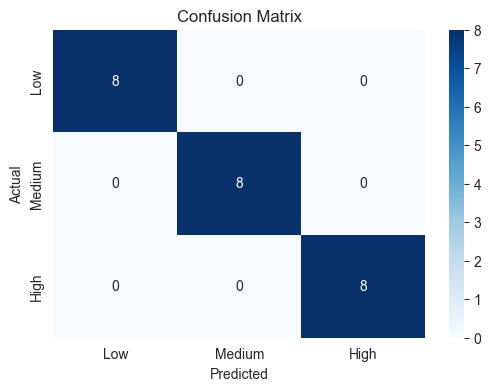

In [79]:
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred),
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=['Low','Medium','High'],
            yticklabels=['Low','Medium','High'])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [80]:
# feature importance
importances = pd.Series( model.feature_importances_,index=X.columns).sort_values(ascending=False)
importances

effectiveness_score           0.347564
avg_quiz_score                0.150571
dropout_rate                  0.122288
completion_rate               0.114494
avg_score_improvement         0.112319
feedback_response_rate        0.068998
avg_feedback_score            0.040856
forum_activity_rate           0.019574
avg_watch_time                0.008602
num_batches                   0.007490
assignment_submission_rate    0.007243
dtype: float64

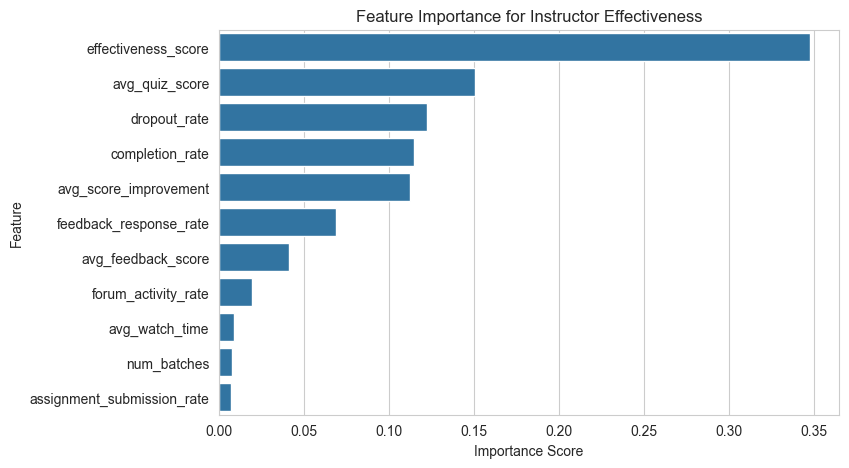

In [81]:
plt.figure(figsize=(8,5))
sns.barplot(x=importances, y=importances.index)
plt.title("Feature Importance for Instructor Effectiveness")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()

## Identifying and Fixing Target Leakage

The initial model achieved **perfect accuracy (1.0)** on the test set. While this may appear impressive, it indicates a potential issue in the modeling pipeline.

Upon reviewing the feature set, i noticed that the variable **`effectiveness_score`** was included as an input feature while the target variable **`effectiveness_tier`** was directly derived from this score.

Because the tier labels were created by splitting the effectiveness score into quantile-based categories, including the score itself as a feature allows the model to easily reconstruct the target variable. This phenomenon is known as **target leakage**, where information used to create the target variable is inadvertently included in the model features.

As a result, the model learns a trivial mapping from:

`effectiveness_score → effectiveness_tier`

rather than learning meaningful relationships between instructor performance metrics and effectiveness.

To prevent this issue and obtain a more realistic evaluation of model performance, the **effectiveness_score column is removed from the training features** before retraining the model.

The first model was intentionally run to illustrate the issue of target leakage.
The final model below removes the effectiveness_score feature.

In [82]:
# Remove columns that should not be used for prediction
X = instructor_df.drop(
    ['instructor_id', 'effectiveness_tier', 'effectiveness_score'],
    axis=1
)

y = instructor_df['effectiveness_tier']

In [83]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42,stratify=y)

In [84]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [85]:
model = RandomForestClassifier(n_estimators=100,random_state=42)
model.fit(X_train_scaled, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [86]:
y_pred = model.predict(X_test_scaled)

In [87]:
accuracy = accuracy_score(y_test, y_pred)
print("Model Accuracy:", accuracy)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Model Accuracy: 0.7916666666666666

Classification Report:

              precision    recall  f1-score   support

        High       1.00      0.88      0.93         8
         Low       1.00      0.50      0.67         8
      Medium       0.62      1.00      0.76         8

    accuracy                           0.79        24
   macro avg       0.87      0.79      0.79        24
weighted avg       0.87      0.79      0.79        24



In [88]:
# Cross-Validation for More Reliable Evaluation
from sklearn.model_selection import cross_val_score
cv_scores = cross_val_score(model, X, y, cv=5)
print("Cross Validation Scores:", cv_scores)
print("Average CV Score:", cv_scores.mean())

Cross Validation Scores: [0.83333333 0.95833333 0.83333333 0.95833333 0.91666667]
Average CV Score: 0.9


In [46]:
importances = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

importances

avg_quiz_score                0.224469
completion_rate               0.215802
dropout_rate                  0.188355
avg_score_improvement         0.158387
feedback_response_rate        0.077039
avg_feedback_score            0.057656
forum_activity_rate           0.035508
avg_watch_time                0.016176
assignment_submission_rate    0.015953
num_batches                   0.010655
dtype: float64

## Model Performance After Removing Target Leakage

After removing the `effectiveness_score` feature from the training data, the model performance became more realistic.

### Test Set Performance

Model Accuracy: **0.79**

Classification results:

| Class | Precision | Recall | F1-score |
|------|-----------|-------|---------|
| High | 1.00 | 0.88 | 0.93 |
| Low | 1.00 | 0.50 | 0.67 |
| Medium | 0.62 | 1.00 | 0.76 |

This indicates that the model is reasonably good at identifying **High** and **Medium** effectiveness instructors, but it struggles more with correctly identifying **Low** effectiveness instructors.

The lower recall for the *Low* class suggests that some instructors who belong to the low-effectiveness category are being misclassified as medium.

### Cross-Validation Results

5-fold cross validation scores:

0.83, 0.96, 0.83, 0.96, 0.92  

Average CV Score: **0.90**

Cross-validation provides a more reliable estimate of model performance because it evaluates the model across multiple train-test splits. The average score of ~0.90 suggests that the model performs consistently across different subsets of the data.

### Interpretation

The difference between the **test accuracy (0.79)** and the **cross-validation average (~0.90)** may occur due to the small dataset size (only ~120 instructors). With limited samples, performance estimates can vary depending on how the data is split.

Overall, the model demonstrates a reasonable ability to identify instructor effectiveness tiers using engagement, outcome, and feedback metrics.

## 1. Which features most influenced instructor effectiveness, and why?

Feature importance analysis from the Random Forest model indicates that the most influential predictors were:

| Feature | Importance |
|-------|-------------|
| avg_quiz_score | 0.224 |
| completion_rate | 0.216 |
| dropout_rate | 0.188 |
| avg_score_improvement | 0.158 |

These variables are primarily related to **learner outcomes**, suggesting that student learning performance is the strongest indicator of instructor effectiveness in the model.

- **Average quiz score** was the most influential feature. This likely reflects how well students understand course material during the learning process.
- **Completion rate** also played a major role, indicating that effective instructors may keep students engaged and motivated to finish the course.
- **Dropout rate** is strongly related to completion rate but captures the opposite outcome, representing student disengagement or difficulty with the course.
- **Average score improvement** measures learning gain, which directly reflects instructional effectiveness.

Interestingly, engagement metrics such as watch time or forum activity had lower importance. This suggests that while engagement contributes to the learning environment, **actual learning outcomes appear to be stronger predictors of instructor effectiveness in this dataset**.

## 2. Which variables could be misleading or confounded?

Some variables in the dataset may not purely reflect instructor performance and could be influenced by external factors.

**Course difficulty**
- Courses that are inherently more difficult may naturally have lower completion rates and lower quiz scores, regardless of instructor quality.

**Student background**
- Learners with stronger prior knowledge may achieve higher quiz scores and improvements even if the instructor's teaching quality is average.

**Feedback response rate**
- Only a subset of students typically leave feedback, which may introduce bias if highly satisfied or dissatisfied learners are more likely to respond.

**Forum activity rate**
- Some courses naturally require more discussion (e.g., project-based courses), while others may be self-paced and require little interaction.

Because of these factors, some variables may capture **course structure or student characteristics rather than instructor performance alone**.

## 3. How could this model fail in real-world usage?

Several factors could limit the reliability of this model in a real EdTech environment.

**Small dataset size**
The instructor-level dataset contains only around 120 instructors, which limits the model's ability to learn complex patterns and may cause unstable predictions.

**Course-level differences**
Different courses may have varying difficulty levels, content formats, or student demographics. Without accounting for these differences, the model may unfairly penalize instructors teaching harder courses.

**Student motivation**
Some batches may contain highly motivated learners, while others may not. These differences can influence completion rates and quiz scores independently of instructor quality.

**Temporal effects**
Instructor performance may change over time as they gain experience or adapt their teaching style. A static model may fail to capture such improvements.

Because of these limitations, the model should be interpreted as a **decision-support tool rather than a definitive measure of instructor effectiveness**.

## 4. What additional data would improve the analysis?

Several additional variables could improve the accuracy and fairness of the model.

**Instructor-related data**
- Years of teaching experience
- Instructor training or certification
- Response time to student questions

**Course-related data**
- Course difficulty level
- Course duration
- Class size or number of enrolled learners

**Student-related data**
- Prior knowledge or pre-course assessment scores
- Student demographics or educational background

**Engagement quality metrics**
- Instructor participation in forums
- Quality of assignment feedback
- Live session attendance

Including these variables would allow the model to better separate **instructor performance from contextual factors**, resulting in more reliable predictions.

## 5. Should this model be used for instructor performance evaluation?

While the model provides useful insights, it should not be used as the sole method for evaluating instructor performance.

The model relies on quantitative metrics such as quiz scores, completion rates, and engagement indicators. However, these metrics may be influenced by external factors such as course difficulty, student motivation, or learner background.

Using the model as the only evaluation tool could therefore lead to unfair conclusions about instructor quality.

Instead, the model should be used as a **decision-support system** to help identify patterns and highlight instructors who may need additional support or recognition.

For example, the model could be used to:

- Identify instructors who consistently achieve strong learner outcomes
- Detect courses where engagement or completion rates are unusually low
- Support instructor training and improvement programs

Combining model insights with **qualitative evaluations, peer reviews, and student feedback** would lead to a more balanced and fair assessment of instructor effectiveness.

## Limitations of the Analysis

While the model provides useful insights into instructor effectiveness, several limitations should be acknowledged.

### Limited Dataset Size
After aggregating to the instructor level, the dataset contains only around 120 instructors.  
Such a small dataset limits the ability of machine learning models to learn complex patterns and increases the risk of overfitting.

### Simplified Effectiveness Definition
The instructor effectiveness score was constructed using a weighted combination of available metrics.  
Although this provides a reasonable proxy, the weights were chosen based on assumptions rather than empirical validation, which may introduce bias into the effectiveness tiers.

### Lack of Contextual Variables
The dataset does not include important contextual information such as course difficulty, student demographics, or instructor experience.  
These factors could significantly influence completion rates, quiz scores, and engagement metrics.

### Batch-Level Averaging
Aggregating metrics using averages may hide important variations across different batches.  
For example, an instructor may perform very well in some batches but poorly in others, which would not be captured fully by simple averages.

### Correlated Features
Some variables, such as completion rate and dropout rate, are highly correlated.  
This may reduce the independence of predictors and affect the interpretability of feature importance results.

Because of these limitations, the model results should be interpreted cautiously and used primarily for exploratory insights rather than definitive conclusions.

## Conclusion and Business Insights

This analysis aimed to estimate instructor effectiveness using learner outcomes, engagement metrics, and student feedback data.

The process involved:

1. Performing exploratory data analysis to understand relationships between variables.
2. Designing a composite instructor effectiveness score based on learning outcomes, engagement, and satisfaction metrics.
3. Aggregating batch-level data to the instructor level to evaluate overall teaching performance.
4. Training a machine learning model to predict instructor effectiveness tiers.

After removing target leakage and retraining the model, the Random Forest classifier achieved a test accuracy of approximately **0.79**, with cross-validation performance around **0.90**.  
Feature importance analysis showed that **learning outcome metrics (quiz scores, completion rate, and score improvement)** were the strongest predictors of instructor effectiveness.

### Practical Applications for an EdTech Platform

The insights from this model could support several platform decisions:

- **Instructor Development:** Identify instructors who may benefit from additional training or mentorship.
- **Best Practice Identification:** Analyze teaching strategies used by highly effective instructors.
- **Early Warning System:** Detect batches where engagement or completion rates are unusually low.
- **Course Assignment Optimization:** Assign high-impact courses to instructors with consistently strong performance metrics.

However, such models should not replace human judgment. Instead, they should serve as **analytical tools that help educational organizations make more informed decisions while considering broader contextual factors**.

Overall, this analysis demonstrates how educational data can be leveraged to gain insights into teaching effectiveness and improve learning outcomes at scale.